In [64]:
import pandas as pd
# --- 3. EDA VISUALS (Before SQL) ---
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [ ]:
#DATA INGESTION
df=pd.read_csv("D:\customer behaviour\customer_shopping_behavior.csv")

<>:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\chhav\AppData\Local\Temp\ipykernel_25100\1909462672.py:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  df=pd.read_csv("D:\customer behaviour\customer_shopping_behavior.csv")


In [66]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [ ]:
#DATA CLEANING & STANDARDIZATION

df.info() #to know the overall structure 

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [68]:
df.describe(include='all') # to check the summary statistics 

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [69]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [70]:
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [71]:
df.isnull().sum()


Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [ ]:
#Standardizing column names for SQL compatibility

df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(' ','_')



In [73]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [74]:
df = df.rename(columns={'purchase_amount_(usd)': 'purchase_amount'})
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [ ]:
#Creating Age Segments for targeted demographic analysis

labels=["young adults","adults","mid aged","senior"]
df['age groups']=pd.qcut(df['age'],q=4,labels=labels)
df [['age','age groups']].head(10)

,age,age groups
0,55,mid aged
1,19,young adults
2,50,mid aged
3,21,young adults
4,45,mid aged
5,46,mid aged
6,63,senior
7,27,young adults
8,26,young adults
9,57,mid aged


In [ ]:
#FEATURE ENGINEERING
frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [77]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [ ]:
#Dropping redundant columns (Maintaining data efficiency)

df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [79]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [80]:
df = df.drop('promo_code_used', axis=1)

In [81]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age groups', 'purchase_frequency_days'],
      dtype='str')

C:\Users\chhav\AppData\Local\Temp\ipykernel_25100\3293712498.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Subscriber', 'Non-Subscriber'])


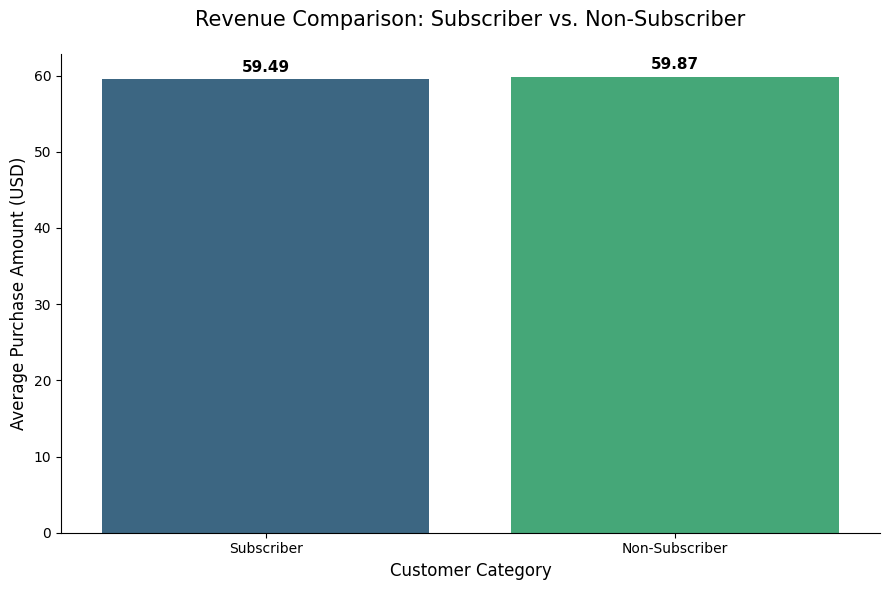

In [ ]:
#EXPLORATORY DATA ANALYSIS (EDA)

# 1. Setup the figure
plt.figure(figsize=(9, 6))

# 2. Create the barplot
# We use 'hue' to ensure Seaborn treats them as distinct groups for labeling
ax = sns.barplot(
    x='subscription_status', 
    y='purchase_amount', 
    data=df, 
    palette='viridis', 
    errorbar=None,
    hue='subscription_status',
    legend=False
)

# 3. ADD LABELS TO ALL BARS
# We loop through containers to make sure both 'Yes' and 'No' get a label
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=11, fontweight='bold')

# 4. CUSTOMIZING AXIS LABELS
plt.title('Revenue Comparison: Subscriber vs. Non-Subscriber', fontsize=15, pad=20)
plt.ylabel('Average Purchase Amount (USD)', fontsize=12)
plt.xlabel('Customer Category', fontsize=12)

# This renames the 'Yes/No' on the bottom to full words
ax.set_xticklabels(['Subscriber', 'Non-Subscriber'])

# 5. Final Polish
sns.despine() # Removes the top and right borders for a modern look
plt.tight_layout()
plt.show()

In [94]:
pip install pymysql sqlalchemy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [95]:


# MySQL connection
username = "root"
password = "1234"
host = "127.0.0.1"
port = "3306"
database = "customer_behaviour"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Write DataFrame to MySQL
table_name = "customer"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

# Read back sample
pd.read_sql("SELECT * FROM customer LIMIT 10;", engine)

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age groups,purchase_frequency_days,loyalty_score
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,mid aged,14,7.093590
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,young adults,14,7.541026
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,mid aged,7,9.547436
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,young adults,7,9.834615
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,mid aged,365,0.552564
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Standard,Yes,14,Venmo,Weekly,mid aged,7,6.335897
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Free Shipping,Yes,49,Cash,Quarterly,senior,90,3.980769
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Free Shipping,Yes,19,Credit Card,Weekly,young adults,7,7.753846
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Express,Yes,8,Venmo,Annually,young adults,365,1.553846
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,2-Day Shipping,Yes,4,Cash,Quarterly,mid aged,90,1.902564


In [97]:
# --- FINAL ANALYST INSIGHTS ---
print("--- PROJECT INSIGHTS SUMMARY ---")

# Insight 1: Gender Distribution
gender_counts = df['gender'].value_counts(normalize=True) * 100
print(f"1. Demographic: The dataset is {gender_counts['Male']:.1f}% Male and {gender_counts['Female']:.1f}% Female.")

# Insight 2: Top Category by Revenue
top_cat = df.groupby('category')['purchase_amount'].sum().idxmax()
total_rev = df.groupby('category')['purchase_amount'].sum().max()
print(f"2. Revenue: '{top_cat}' is the top-performing category with ${total_rev:,.2f} in total sales.")

# Insight 3: Subscription Value
sub_avg = df.groupby('subscription_status')['purchase_amount'].mean()
print(f"3. Loyalty: Subscribers spend an average of ${sub_avg['Yes']:.2f} vs ${sub_avg['No']:.2f} for non subscribers .")

print("--------------------------------")

--- PROJECT INSIGHTS SUMMARY ---
1. Demographic: The dataset is 68.0% Male and 32.0% Female.
2. Revenue: 'Clothing' is the top-performing category with $104,264.00 in total sales.
3. Loyalty: Subscribers spend an average of $59.49 vs $59.87 for non subscribers .
--------------------------------
